# IMPORT LIBRARY

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

# CONNECTING TO DATABASE

In [33]:
load_dotenv("../.env")

conn = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connection created")

Connection created


# SALES & FINANCIAL PERFORMANCE ANALYSIS

## RETRIVE DATA

In [34]:
dataset = '''SELECT
                t.transaction_id
                ,t.deal_date
                ,t.city
                ,t.deal_status
                ,t.payment_mode
                ,t.deal_price
                ,t.commission_amount
                ,l.listing_id
                ,l.listing_date
                ,l.listed_price
                ,l.days_on_market
                ,l.listing_status
                ,l.close_date
                ,p.property_id
                ,p.property_type
            FROM transactions t
            FULL OUTER JOIN listings l ON l.listing_id = t.listing_id
            LEFT JOIN properties p ON l.property_id = p.property_id
            WHERE DATE_PART('year',listing_date)<=2024 '''

df_dataset = pd.read_sql(dataset,conn)

In [35]:
df_dataset['deal_date'] = (\
    pd.to_datetime(df_dataset['deal_date'])
    .astype('datetime64[ns]')
)

df_dataset['listing_date'] = (\
    pd.to_datetime(df_dataset['listing_date'])
    .astype('datetime64[ns]')
)

df_dataset['close_date'] = (\
    pd.to_datetime(df_dataset['close_date'])
    .astype('datetime64[ns]')
)

In [36]:
df_completed = (\
    df_dataset[(df_dataset['deal_status']=='Completed')&
               ((df_dataset['close_date'].dt.year)<=2024)]
                .reset_index(drop = True)
)

df_completed['year'] = df_completed['deal_date'].dt.year
df_completed['quarter'] = df_completed['deal_date'].dt.quarter
df_completed["month"] = df_completed["deal_date"].dt.month

## BASELINE FINANCIALS

>1) Revenue Overview

In [37]:
gross_rev = df_completed['listed_price'].sum()
total_rev = df_completed['deal_price'].sum()
net_rev = (\
    (df_completed['deal_price'].sum()) 
    - (df_completed['commission_amount'].sum())
)

print("----------- Revenue Summary -----------")
print(f"\nTotal Completed Transaction  : {len(df_completed)}")
print(f"Gross Revenue (Listed Price) : {gross_rev/1e9:.2f}B")
print(f"Total Revenue (Deal Price)   : {total_rev/1e9:.2f}B")
print(f"Net Revenue                  : {net_rev/1e9:.2f}B")

----------- Revenue Summary -----------

Total Completed Transaction  : 3737
Gross Revenue (Listed Price) : 51.79B
Total Revenue (Deal Price)   : 51.54B
Net Revenue                  : 50.27B


>2) Revenue Distribution

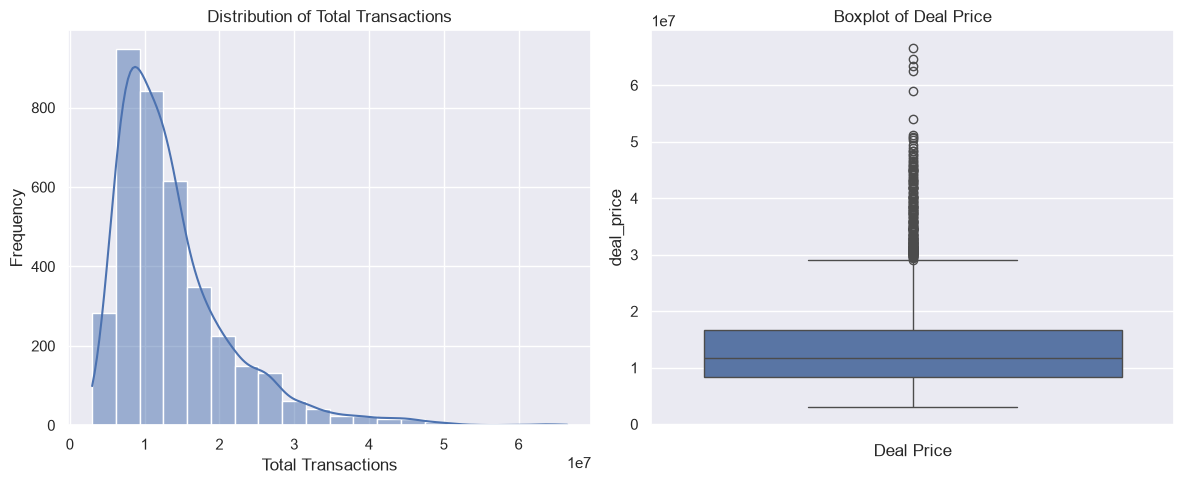

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    data=df_completed,
    x='deal_price',
    bins=20,
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Distribution of Total Transactions')
axes[0].set_xlabel('Total Transactions')
axes[0].set_ylabel('Frequency')

sns.boxplot(\
    data= df_completed['deal_price'],
    ax=axes[1]
)

axes[1].set_title('Boxplot of Deal Price')
axes[1].set_xlabel('Deal Price')

plt.tight_layout()
plt.show()

>> The revenue distribution is mostly concentrated in lower priced to mid priced properties, with a median deal value of around BDT 12M. Half of the transactions were within the BDT 8–17 M range, showing that most properties were sold at relatively affordable price levels. However, a small number of high-value transactions exceeded BDT 30 M, with the highest reaching BDT 65 M, indicating the presence of a smaller luxury property segment.

> 3) Revenue Driver

In [39]:
data1 = (\
    df_completed
    .groupby(['year','month'])
    .agg(total_rev = ('deal_price','sum'),
         total_trans = ('deal_price','count'),
         avg_rev = ('deal_price','mean'))
    )

data1

total_rev  total_trans       avg_rev
year month                                         
2022 1      1.854321e+08           12  1.545268e+07
     2      7.259246e+08           50  1.451849e+07
     3      1.358215e+09          103  1.318655e+07
     4      1.410136e+09          100  1.410136e+07
     5      1.489930e+09          100  1.489930e+07
     6      1.589650e+09          113  1.406770e+07
     7      1.528907e+09          109  1.402667e+07
     8      1.476077e+09          113  1.306263e+07
     9      1.440997e+09          107  1.346727e+07
     10     1.423840e+09          109  1.306276e+07
     11     1.354706e+09          100  1.354706e+07
     12     1.411638e+09          105  1.344417e+07
2023 1      1.285279e+09           93  1.382020e+07
     2      1.372753e+09          100  1.372753e+07
     3      1.307414e+09           99  1.320620e+07
     4      1.352378e+09          101  1.338988e+07
     5      1.685164e+09          109  1.546022e+07
     6      1.483818e+09          113  1.313113e+07
     7      1.293202e+09           89  1.453036e+07
     8      1.421854e+09          104  1.367167e+07
     9      1.686339e+09          123  1.371007e+07
     10     1.572077e+09          120  1.310064e+07
     11     1.597517e+09          108  1.479182e+07
     12     1.554468e+09          120  1.295390e+07
2024 1      1.398238e+09           96  1.456498e+07
     2      1.426315e+09          106  1.345580e+07
     3      1.386612e+09          104  1.333281e+07
     4      1.740550e+09          127  1.370512e+07
     5      1.531968e+09          107  1.431746e+07
     6      1.413761e+09          104  1.359386e+07
     7      1.541740e+09          113  1.364372e+07
     8      1.948894e+09          130  1.499149e+07
     9      1.597495e+09          112  1.426335e+07
     10     1.392017e+09          104  1.338478e+07
     11     1.578930e+09          119  1.326832e+07
     12     1.577473e+09          115  1.371715e+07

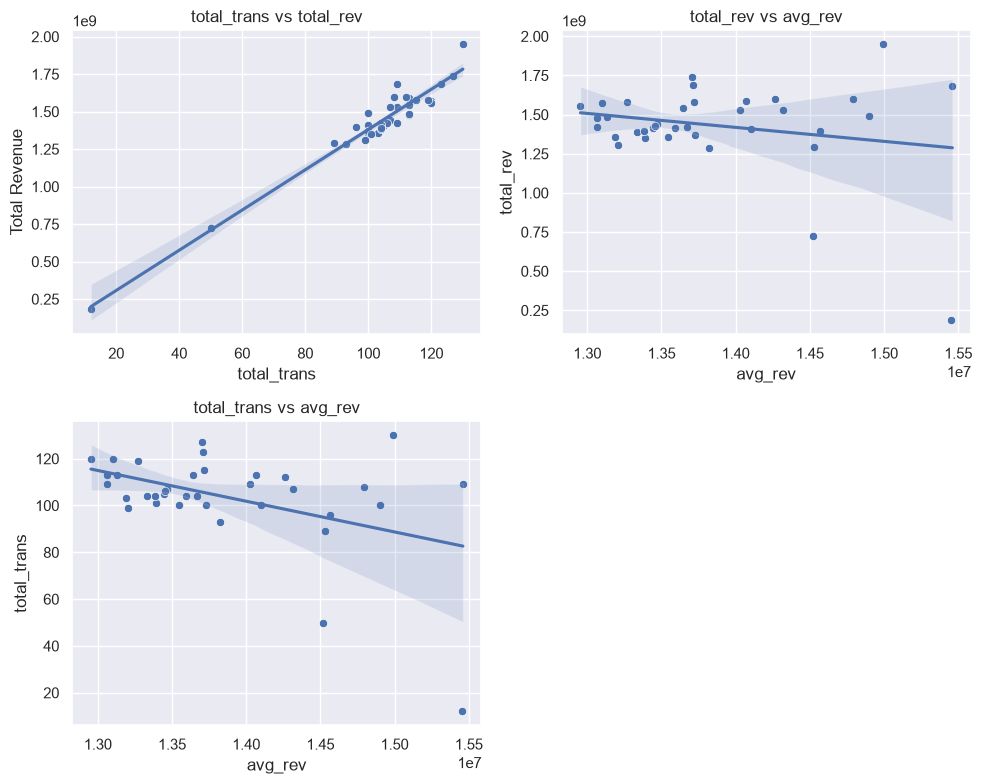

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))


sns.scatterplot(\
    data = data1,
    x = 'total_trans',
    y='total_rev',
    ax = axes[0,0]
)

sns.regplot(\
    data=data1,
    x='total_trans',
    y='total_rev',
    scatter=False,
    ax = axes[0,0]
)

axes[0,0].set_title('total_trans vs total_rev')
axes[0,0].set_xlabel('total_trans')
axes[0,0].set_ylabel('Total Revenue')


sns.scatterplot(\
    data = data1,
    x = 'avg_rev',
    y='total_rev',
    ax = axes[0,1]
)

sns.regplot(
    data=data1,
    x='avg_rev',
    y='total_rev',
    scatter=False,
    ax = axes[0,1]
)

axes[0,1].set_title('total_rev vs avg_rev')
axes[0,1].set_xlabel('avg_rev')
axes[0,1].set_ylabel('total_rev')


sns.scatterplot(
    data = data1,
    x = 'avg_rev',
    y='total_trans',
    ax = axes[1,0]
)

sns.regplot(
    data=data1,
    x='avg_rev',
    y='total_trans',
    scatter=False,
    ax = axes[1,0]
)

axes[1,0].set_title('total_trans vs avg_rev')
axes[1,0].set_xlabel('avg_rev')
axes[1,0].set_ylabel('total_trans')


axes[1,1].axis('off')

plt.tight_layout()
plt.show()

A scatter plot was used to examine the relationship and correlation pattern

In [41]:
from scipy.stats import shapiro

for col in ['total_trans', 'total_rev', 'avg_rev']:
    stat, p = shapiro(data1[col])
    print(f'{col}: p-value = {p:.4f}')

total_trans: p-value = 0.0000
total_rev: p-value = 0.0000
avg_rev: p-value = 0.0084


The Shapiro-Wilk test was conducted to determine whether the data followed a normal distribution

Spearman correlation was selected because the variables showed skewed distributions, violated normality assumptions based on the Shapiro-Wilk test (p < 0.05), and contained several outliers. This method provides a more robust measurement of the relationship between business metrics.

In [42]:
data1.corr(method = 'spearman')

,total_rev,total_trans,avg_rev
total_rev,1.000000,0.890740,0.106049
total_trans,0.890740,1.000000,-0.273866
avg_rev,0.106049,-0.273866,1.000000


A strong positive correlation (r = 0.89) between total transactions and total revenue indicates that revenue growth was primarily driven by transaction volume. In contrast, average revenue showed a very weak correlation with total revenue (r = 0.11), suggesting that higher transaction values alone were insufficient to increase revenue without a high number of transactions. The negative correlation between average revenue and total transactions further suggests that periods with higher transaction volumes included more lower value deals, reducing the average revenue per transaction.

In [43]:
data1.describe()

,total_rev,total_trans,avg_rev
count,3.600000e+01,36.000000,3.600000e+01
mean,1.431714e+09,103.805556,1.384914e+07
std,2.840494e+08,20.572963,6.800546e+05
min,1.854321e+08,12.000000,1.295390e+07
25%,1.383147e+09,100.000000,1.337179e+07
50%,1.433656e+09,106.500000,1.368839e+07
75%,1.573426e+09,113.000000,1.427687e+07
max,1.948894e+09,130.000000,1.546022e+07


In [44]:
import statsmodels.api as sm

x = data1['total_trans']
y = data1['total_rev']

x_log = np.log1p(x)
y_log = np.log1p(y)

x_log = sm.add_constant(x_log)
model = sm.OLS(y_log,x_log).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              total_rev   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     2492.
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           2.13e-33
Time:                        09:21:43   Log-Likelihood:                 62.389
No. Observations:                  36   AIC:                            -120.8
Df Residuals:                      34   BIC:                            -117.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          16.5515      0.090    183.496      

In [45]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    model.resid,
    model.model.exog
)

labels = [
    'LM Statistic',
    'LM-Test p-value',
    'F Statistic',
    'F-Test p-value'
]

dict(zip(labels, bp_test))

{'LM Statistic': np.float64(0.9185501320872875),
 'LM-Test p-value': np.float64(0.33785594841188543),
 'F Statistic': np.float64(0.8902341439295256),
 'F-Test p-value': np.float64(0.35207062228682523)}

>>The OLS regression analysis demonstrates that transaction volume is a key driver of monthly revenue perfromance.
Explaining 94.4% of revenue variation (R² = 0.944, F = 575.8, p < 0.001).**On average, an additional transaction is associated with an estimated increase of BDT 13.42 million in revenue (p < 0.001)**.

>4) Discount Overview

In [46]:
df_completed['diff_price'] = (\
    df_completed['listed_price'] - 
    df_completed['deal_price']
)

df_completed['pricing_status'] = (\
    np.select(
    [
        df_completed['deal_price'] < df_completed['listed_price'],
        df_completed['deal_price'] == df_completed['listed_price'],
        df_completed['deal_price'] > df_completed['listed_price']
    ],
    [
        'Discount',
        'At List Price',
        'Premium'
    ],
    default = 'Unknown')
)

price_realization_rate = (\
    round(
        (total_rev/df_completed['listed_price']
         .sum())
        *100,2
        )
    )


pricing_status_distribution = (
    round(
        (df_completed['pricing_status'].value_counts() /
         df_completed['transaction_id'].count())
        * 100,2
    )
)

total_discount_impact = (\
    (df_completed.loc[df_completed['pricing_status']=='Discount','diff_price'])
    .sum()
)

total_listed_price = (\
    (df_completed.loc[df_completed['pricing_status']=='Discount','listed_price'])
    .sum()
)

price_discount_rate = (\
    round(
    (total_discount_impact/total_listed_price)
    *100,2)
)


print("----------- Discount Analysis Summary -----------")
print("\nPrice Realization Rate :", price_realization_rate,"%")
print("\nPricing Status Distribution :")
for x, y in pricing_status_distribution.items():
    print(f"{x} : {y} %")
print(f"\nTotal Discount Impact : {total_discount_impact/1e6:.2f}M")
print("Discount Rate :", price_discount_rate,"%")




----------- Discount Analysis Summary -----------

Price Realization Rate : 99.52 %

Pricing Status Distribution :
Discount : 59.62 %
Premium : 40.38 %

Total Discount Impact : 954.84M
Discount Rate : 3.34 %


>> Although 59.62% of transactions were closed below the listed price, the overall price realization rate remained high at 99.52%, indicating that final transaction prices were generally close to the initial listing values. This suggests that price negotiations were common in the market, but the average adjustment from listed prices was relatively small. Discounted transactions resulted in a total price adjustment of BDT 954.84 million, with an average discount rate of 3.34%. Meanwhile, premium transactions contributed to maintaining strong overall price realization performance

>5) Commission Overview

In [47]:
total_incentive_expense = (\
    df_completed['commission_amount']
    .sum()
)

commission_expense_rate = (\
    round(
        (total_incentive_expense/total_rev)
        *100,2
        )
)

print("----------- Commission Analysis Summary -----------")
print(f"\nTotal Incentive Expense  : {total_incentive_expense/1e9:.2f}B")
print(f"Commission Expense Rate   : {commission_expense_rate:.2f}%")

----------- Commission Analysis Summary -----------

Total Incentive Expense  : 1.28B
Commission Expense Rate   : 2.48%


>> Commission expenses amounted to BDT 1.28 billion, accounting for 2.48% of total revenue. The relatively low commission expense ratio indicates that the company was able to generate revenue while maintaining controlled incentive costs.

## SALES VOLUME AND PRICING EFFICIENCY

> 1) Transaction Overview

In [48]:
df_transaction = (\
    df_dataset[
        ((df_dataset['close_date'].dt.year)<=2024)
          & (~df_dataset['deal_status'].isna())
          ]
)

total_transaction = (\
    df_transaction['transaction_id']
    .count()
)

total_disputed_transaction = (\
    df_transaction[df_transaction['deal_status']=='Disputed']
    ['transaction_id']
)

AVG_Selling_Price = (total_rev/total_transaction).round(2)


print("----------- Transaction Analysis Summary -----------")
print(f"\nTotal Transactions           : {total_transaction}")
print(f"Total Completed Transactions : {len(df_completed)} ")
print(f"Total Disputed Transactions  : {len(total_disputed_transaction)}")
print(f"Deal Completion Rate         : {(len(df_completed))/total_transaction*100:,.2f} %")
print(f"Average Selling Price        : {AVG_Selling_Price/1e6:.2f} M")


----------- Transaction Analysis Summary -----------

Total Transactions           : 3776
Total Completed Transactions : 3737 
Total Disputed Transactions  : 39
Deal Completion Rate         : 98.97 %
Average Selling Price        : 13.65 M


## GROWTH MARKET AND VELOCITY

>1) Annual Revenue and Transaction Analysis

In [49]:

rev_year = (\
    df_completed
    .groupby(df_completed['year'])
    .agg(total_rev=('deal_price', 'sum'),
        total_trans = ('transaction_id','count'))
    .reset_index()
    .sort_values(['year'])
)

rev_year['prev_rev'] = rev_year['total_rev'].shift(1)

rev_year['YoY_growth'] = (\
        round(
            (rev_year['total_rev']-rev_year['prev_rev'])
              /rev_year['prev_rev']
              *100,2
            )
)


print('----------Annual Revenue Performance-----------')
print(f"\nAverage Annual Revenue = {(rev_year['total_rev'].mean()/1e9):.2f}B")
rev_year


----------Annual Revenue Performance-----------

Average Annual Revenue = 17.18B


,year,total_rev,total_trans,prev_rev,YoY_growth
0,2022,1.539545e+10,1121,NaN,NaN
1,2023,1.761226e+10,1279,1.539545e+10,14.40
2,2024,1.853399e+10,1337,1.761226e+10,5.23


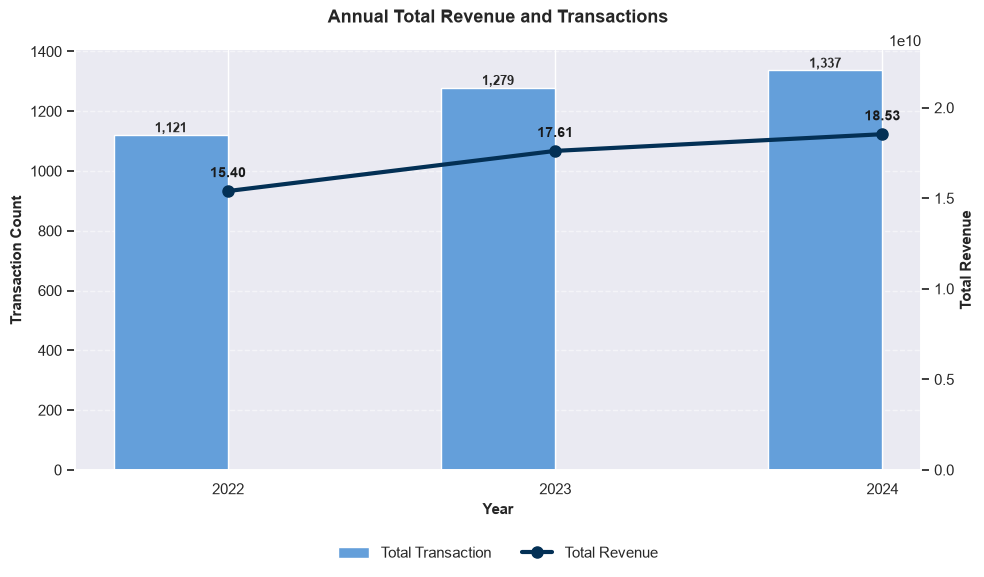

In [50]:
sns.set_style("darkgrid")

fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(rev_year["year"]))
width = 0.35

bars = ax1.bar(
    x - width/2,
    rev_year["total_trans"],
    width,
    color="#649FDA",
    label="Total Transaction"
)

ax1.set_ylabel(
    "Transaction Count",
    fontsize=11,
    fontweight="bold"
)

ax1.set_xlabel(
    "Year",
    fontsize=11,
    fontweight="bold"
)

ax1.set_xticks(x)
ax1.set_xticklabels(
    rev_year["year"].astype(str),
    fontsize=11
)

ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

for bar in bars:
    height = bar.get_height()

    ax1.annotate(
        f"{int(height):,}",
        (
            bar.get_x() + bar.get_width()/2,
            height
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax2 = ax1.twinx()

line_color = "#033055"

ax2.plot(
    x,
    rev_year["total_rev"],
    color=line_color,
    marker="o",
    linewidth=3,
    markersize=8,
    label="Total Revenue"
)

ax2.set_ylabel(
    "Total Revenue",
    fontsize=11,
    fontweight="bold"
)

ax2.set_ylim(
    0,
    rev_year["total_rev"].max() * 1.25
)

ax2.grid(False)

color = "#191A1B"
for i, txt in enumerate(rev_year["total_rev"]):
    ax2.annotate(
        f"{txt/1e9:.2f}",
        (x[i], txt),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        color=color,
        fontweight="bold",
        fontsize=10
    )

plt.title(
    "Annual Total Revenue and Transactions",
    fontsize=13,
    fontweight="bold",
    pad=20
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="none"
)

sns.despine(top=True, right=False)

plt.tight_layout()
plt.show()

>> The annual revenue trend demonstrates consistent year-over-year growth. Revenue increased from approximately BDT 15 billion in 2022 to over BDT 18 billion in 2024, with an average annual revenue of around BDT 17 billion. This indicates sustained business performance and continued growth in revenue generation. However, revenue growth decelerated from 14.40% (2022–2023) to 5.23% (2023–2024), suggesting slower growth momentum in the latest period.

>>Overall, the positive revenue trend highlights stable business growth and strong revenue performance over the analyzed period.

> 2) Quarterly Revenue Analysis

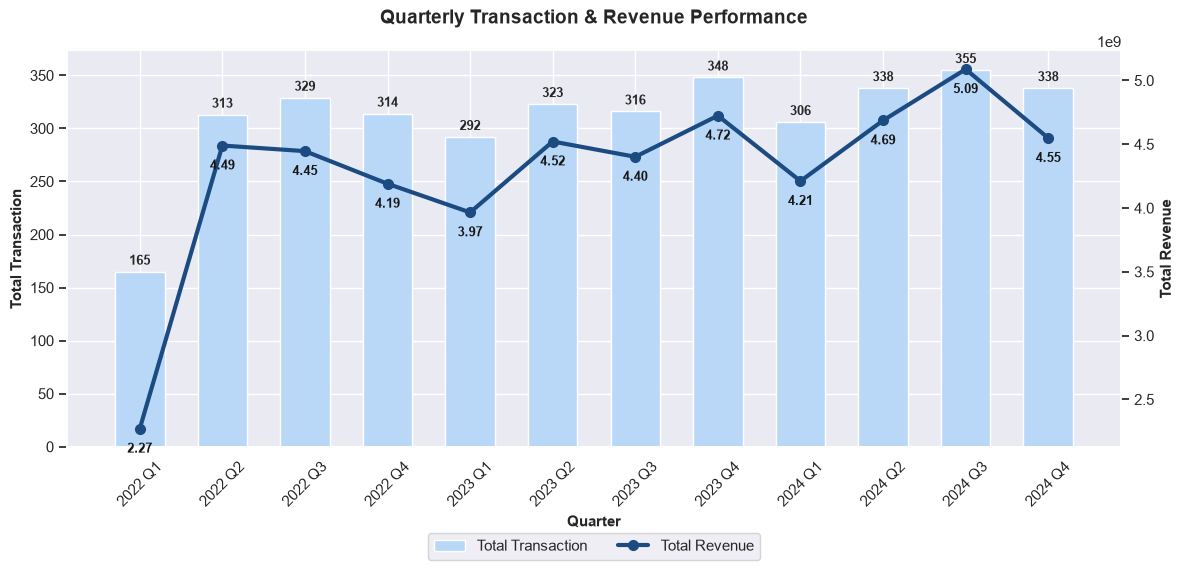

In [51]:
rev_qrt = (
    df_completed
    .groupby(['year', 'quarter'])
    .agg(
        total_rev=('deal_price', 'sum'),
        total_trans=('transaction_id', 'count')
    )
    .reset_index()
    .sort_values(['year', 'quarter'])
)

rev_qrt['quarter_label'] = (
    rev_qrt['year'].astype(str) + 
    ' ' + 
    'Q' + rev_qrt['quarter'].astype(str)
)

sns.set_style('darkgrid')

fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(rev_qrt))
width = 0.6

bars = ax1.bar(
    x,
    rev_qrt['total_trans'],
    width=width,
    color="#B9D8F8",
    label='Total Transaction'
)

ax1.set_xlabel('Quarter', fontsize=11, fontweight='bold')
ax1.set_ylabel('Total Transaction', fontsize=11, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(
    rev_qrt['quarter_label'],
    rotation=45
)

for bar in bars:
    height = bar.get_height()
    ax1.annotate(
        f'{int(height):,}',
        (bar.get_x() + bar.get_width()/2, height),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax2 = ax1.twinx()

ax2.plot(
    x,
    rev_qrt['total_rev'],
    color="#1B4B81",
    marker='o',
    linewidth=3,
    markersize=7,
    label='Total Revenue'
)

ax2.set_ylabel(
    'Total Revenue',
    fontsize=11,
    fontweight='bold'
)

for i, value in enumerate(rev_qrt['total_rev']):
    ax2.annotate(
        f'{value/1e9:.2f}',
        (x[i], value),
        textcoords='offset points',
        ha='center',
        va = 'top',
        xytext=(0,-10),
        fontsize=9,
        fontweight='bold',
        color="#161616"
    )

ax1.set_title(
    'Quarterly Transaction & Revenue Performance',
    fontsize=14,
    fontweight='bold',
    pad=20
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    bbox_to_anchor=(0.5, -0.2),
    loc='upper center',
    ncol=2,
    frameon=True
)

ax2.grid(False)

sns.despine(top=True, right=False)

plt.tight_layout()
plt.show()

>> The quarterly revenue trend exhibits a recurring seasonal pattern throughout the observation period, with an average quarterly revenue of approximately BDT 4.3 billion.

>> Q1 recorded consistent YoY revenue growth across all observed years compared to the same quarter in the previous year. Although QoQ growth remained negative, the continuous YoY improvement indicates stronger revenue generation at the beginning of each year, reflecting improved transaction performance compared to previous periods.

>> Q2 was the most stable quarter throughout the observation period. Based on QoQ growth, revenue increased consistently every year (+97.82% in 2022, +14.02% in 2023, and +11.28% in 2024), although the growth rate gradually moderated over time, suggesting a more sustainable growth pattern.

>> A significant increase was observed in Q3 2024, when revenue reached a record high of BDT 5.08 billion, representing an 8.58% QoQ increase. However, this upward momentum did not continue into the following quarter. Revenue declined to BDT 4.54 billion in Q4 2024 (-10.61% QoQ), slightly below the Q4 2023 level of BDT 4.72 billion.

>> The weaker QoQ and YoY performance in Q4 2024 warrants further investigation. Additional transaction-level and market-level analyses are needed to determine whether the decline was driven by temporary factors, changes in customer demand, seasonality, or other business conditions.

> 3) Monthly Revenue Analysis

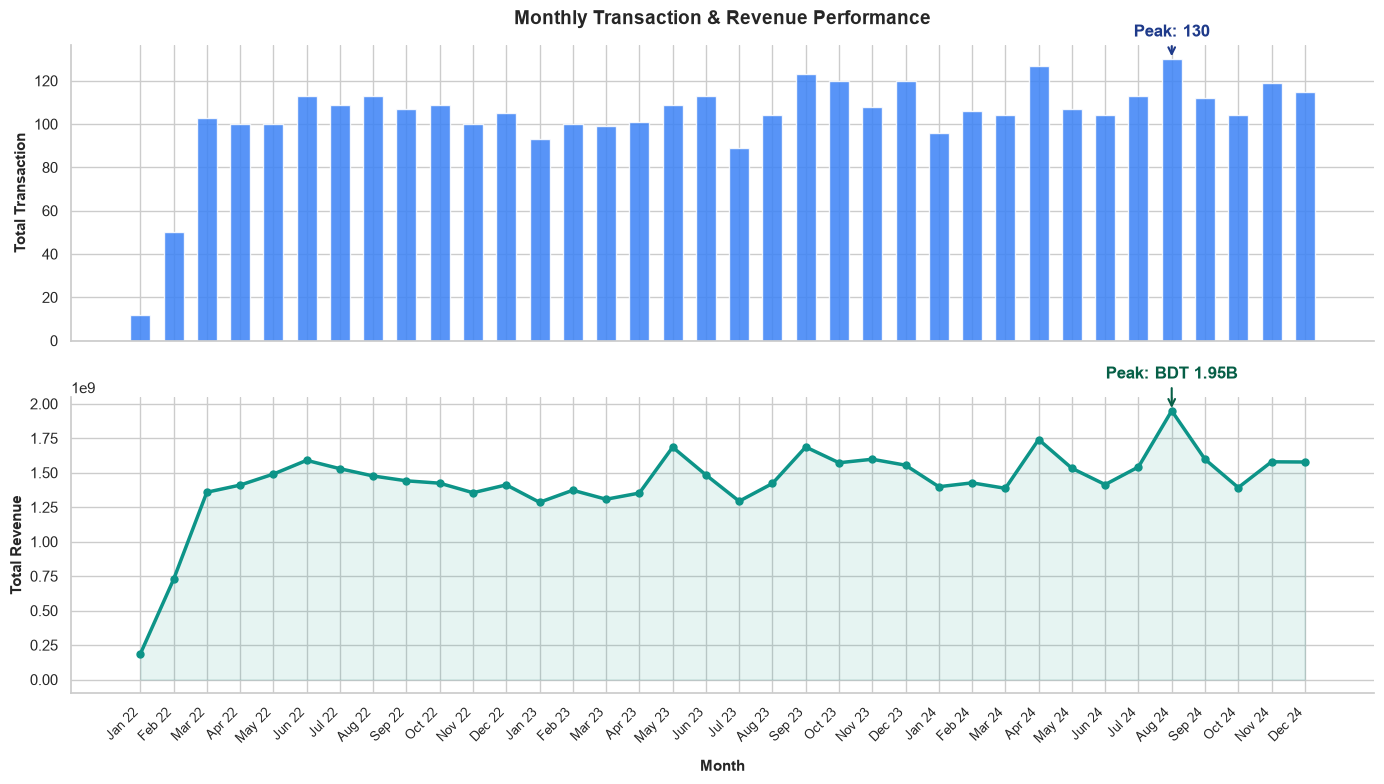

----------------------------Monthly Revenue Performance----------------------------

Average Monthly Revenue     : 1.43B
------------------------------------------------------------------------------------

Highest Revenue Month       : 1.95B (Aug 2024)
Lowest Revenue Month        : 185.43M (Jan 2022)
------------------------------------------------------------------------------------

Highest AVG Revenue Month   : 15.46M (May 2023)
Lowest AVG Revenue Month    : 12.95M (Dec 2023)


In [52]:
import calendar
rev_year_month = (\
    df_completed.groupby(["year", "month"])
    .agg(
        total_rev=("deal_price", "sum"),
        average_rev=("deal_price", "mean"),
        total_trans=("transaction_id", "count"),
    )
    .reset_index()
)

rev_year_month["month_name"] = (\
    rev_year_month["month"]
    .apply(lambda x: calendar.month_abbr[x])
)

rev_year_month.drop(columns="month", inplace=True)

rev_year_month = (\
    rev_year_month[
    ["year", "month_name", "total_rev", 
     "total_trans", "average_rev"]
     ]
)

rev_year_month = (\
    rev_year_month
    .rename(columns={"month_name": "month"})
)

rev_year_month["prev_rev"] = (\
    rev_year_month["total_rev"]
    .shift(1)
)

rev_year_month["MoM_growth"] = (\
    round(
    (
        (rev_year_month["total_rev"] - rev_year_month["prev_rev"])
        / rev_year_month["prev_rev"]
    )
    * 100,
    2)
)


rev_year_month["contribution"] = (\
    round(
    rev_year_month["total_rev"]
    / (rev_year_month.groupby("year")["total_rev"].transform("sum"))
    * 100,
    2)
)

rev_year_month["month_label"] = (\
    rev_year_month["month"].astype(str)
    + " "
    + rev_year_month["year"].astype(str).str[-2:]
)


sns.set_theme(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(\
    2, 1, figsize=(14, 8), sharex=True
    , gridspec_kw={"height_ratios": [1, 1]}
)

x = np.arange(len(rev_year_month))

color_trans = "#3B82F6"
color_rev = "#0D9488"

bars = ax1.bar(\
    x,
    rev_year_month["total_trans"],
    width=0.6,
    color=color_trans,
    alpha=0.85,
    label="Total Transaction",
)


ax1.set_ylabel("Total Transaction", fontsize=11, fontweight="bold")
ax1.set_title(
    "Monthly Transaction & Revenue Performance",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

max_trans_idx = rev_year_month["total_trans"].idxmax()
max_trans_val = rev_year_month["total_trans"].iloc[max_trans_idx]

ax1.annotate(\
    f"Peak: {max_trans_val:,}",
    (max_trans_idx, max_trans_val),
    xytext=(max_trans_idx, max_trans_val + (max_trans_val * 0.08)),
    ha="center",
    fontweight="bold",
    color="#1E3A8A",
    arrowprops=dict(arrowstyle="->", color="#1E3A8A", lw=1.5),
)

ax2.plot(\
    x,
    rev_year_month["total_rev"],
    color=color_rev,
    marker="o",
    linewidth=2.5,
    markersize=5,
    label="Total Revenue",
)
ax2.fill_between(x, rev_year_month["total_rev"], color=color_rev, alpha=0.1)
ax2.set_ylabel("Total Revenue", fontsize=11, fontweight="bold")
ax2.set_xlabel("Month", fontsize=11, fontweight="bold", labelpad=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

max_rev_idx = rev_year_month["total_rev"].idxmax()
max_rev_val = rev_year_month["total_rev"].iloc[max_rev_idx]
ax2.annotate(
    f"Peak: BDT {max_rev_val/1e9:.2f}B",
    (max_rev_idx, max_rev_val),
    xytext=(max_rev_idx, max_rev_val + (max_rev_val * 0.12)),
    ha="center",
    fontweight="bold",
    color="#065F46",
    arrowprops=dict(arrowstyle="->", color="#065F46", lw=1.5),
)

ax2.set_xticks(x)
ax2.set_xticklabels(
    rev_year_month["month_label"], 
    rotation=45, 
    ha="right",
    fontsize=9
)

plt.tight_layout()
plt.show()

print(f'----------------------------Monthly Revenue Performance----------------------------')
print(f"\nAverage Monthly Revenue     : \
{(rev_year_month['total_rev'].mean())/1e9:.2f}B")
print("------------------------------------------------------------------------------------")
max_trans = rev_year_month.loc[rev_year_month['total_rev'].idxmax()]
min_trans = rev_year_month.loc[rev_year_month['total_rev'].idxmin()]
print(f"\nHighest Revenue Month       : \
{max_trans['total_rev']/1e9:.2f}B ({max_trans['month']} {max_trans['year']})")
print(f"Lowest Revenue Month        : \
{min_trans['total_rev']/1e6:.2f}M ({min_trans['month']} {min_trans['year']})")
print("------------------------------------------------------------------------------------")
max_trans_avg = rev_year_month.loc[rev_year_month['average_rev'].idxmax()]
min_trans_avg = rev_year_month.loc[rev_year_month['average_rev'].idxmin()]
print(f"\nHighest AVG Revenue Month   : \
{max_trans_avg['average_rev']/1e6:.2f}M ({max_trans_avg['month']} {max_trans_avg['year']})")
print(f"Lowest AVG Revenue Month    : \
{min_trans_avg['average_rev']/1e6:.2f}M ({min_trans_avg['month']} {min_trans_avg['year']})")

>> 1. January-February 2022 recorded the lowest Revenue throughout the observed period, which may indicate the early stage of business activty. However, a significant increase occurred in March 2022, and Revenue performance began to stabilize in the following months, with an average monthly Revenue of approximately BDT 1.4 billion
>>
>> 2. Revenue continued to increase throughout 2023 and 2024, with both peak Revenue levels and baseline Revenue showing consistent YoY improvements. This indicates a positive growth trend in the business's Revenue performance over the analyzed period.
>>
>> 3. The highest average revenue per transaction did not coincide with the highest total revenue month, suggesting that revenue performance was primarily driven by transaction volume rather than transaction value alone.
>>
>> 4. April and August 2024 recorded the highest Revenue levels during the entire period, generating more than BDT 1.7 billion and BDT 1.9 billion. This pattern may also explain the higher Revenue performance recorded in Q2 and Q3 2024 compared to the corresponding quarters in previous years, respectively. However, Revenue returned to a more normal level in the following months (May and September 2024). This pattern suggests the possibility of high value deals  or high transaction volume contributing to the Revenue spikes observed in April and August 2024. which can be furthur validated through deeper transaction level analysis.
>>
>> 5. Overall, the positive Revenue trend indicates sustained business growth over the observed period. The Revenue peaks in April and August 2024 represent opportunities to further investigate the factors driving these increases and identify potential strategies for maintaining future growth momentum.

> 4) Sales Velocity /Absorption Rate(%)

In [53]:

trans_year = (\
    df_completed
    .groupby('year')
    .agg(total_trans =('listing_id','count'))
    .reset_index()
)


annual_available_listing = []
years = (df_dataset['listing_date'].dt.year).unique()

for year in years:
    start_date = pd.Timestamp(f'{year}-01-01')
    end_date = pd.Timestamp(f'{year}-12-31')
    carry_over = df_dataset[
        (df_dataset['listing_date']< start_date ) &
        ((df_dataset['close_date'] >= start_date)|
         (df_dataset['close_date'].isna()))
    ]

    new_listing = df_dataset[
        (df_dataset['listing_date']>=start_date) &
        ((df_dataset['listing_date']<=end_date))]

    available_listing = (\
    carry_over['listing_id'].nunique() +
    new_listing['listing_id'].nunique()
    )

    annual_available_listing.append(
        {'year': year,
         'available_listing' : available_listing}
    )

annual_available_list = pd.DataFrame(annual_available_listing)

annual_absorption_rate = trans_year.merge(annual_available_list, on = 'year')

annual_absorption_rate['absorption_rate'] = (\
       annual_absorption_rate['total_trans']
       /annual_absorption_rate['available_listing']
         *100).round(2)

annual_absorption_rate



,year,total_trans,available_listing,absorption_rate
0,2022,1121,2879,38.94
1,2023,1279,4285,29.85
2,2024,1337,5318,25.14


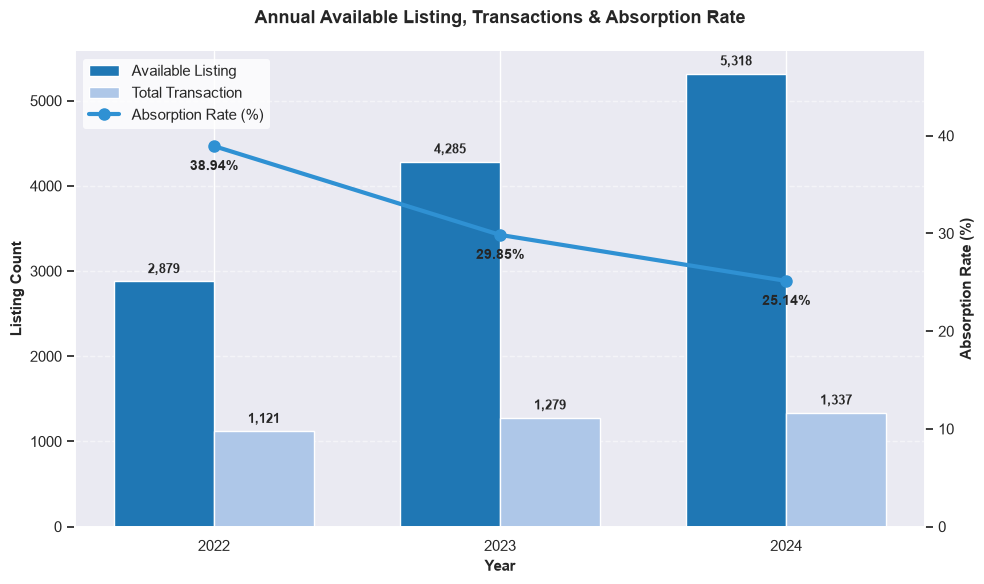

,year,total_trans,available_listing,absorption_rate
0,2022,1121,2879,38.94
1,2023,1279,4285,29.85
2,2024,1337,5318,25.14


In [54]:

sns.set_style("darkgrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(annual_absorption_rate["year"]))
width = 0.35

rects1 = ax1.bar(\
    x - width / 2,
    annual_absorption_rate["available_listing"],
    width,
    label="Available Listing",
    color="#1f77b4",
)

rects2 = ax1.bar(\
    x + width / 2,
    annual_absorption_rate["total_trans"],
    width,
    label="Total Transaction",
    color="#aec7e8",
)

ax1.set_ylabel("Listing Count", fontsize=11, fontweight="bold")
ax1.set_xlabel("Year", fontsize=11, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(annual_absorption_rate["year"].astype(str), fontsize=11)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

for rect in rects1 + rects2:
    height = rect.get_height()
    ax1.annotate(
        f"{int(height):,}",
        xy=(rect.get_x() + rect.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax2 = ax1.twinx()

line_color = "#2f91d3"

line = ax2.plot(\
    x,
    annual_absorption_rate["absorption_rate"],
    color=line_color,
    marker="o",
    linewidth=3,
    markersize=8,
    label="Absorption Rate (%)",
)

ax2.set_ylabel("Absorption Rate (%)", fontsize=11, fontweight="bold")
ax2.tick_params(axis="y")
ax2.grid(False)

max_rate = annual_absorption_rate["absorption_rate"].max()
ax2.set_ylim(0, max_rate * 1.25)

for i, txt in enumerate(annual_absorption_rate["absorption_rate"]):
    ax2.annotate(\
        f"{txt:.2f}%",
        (x[i], txt),
        textcoords="offset points",
        xytext=(0, -10),
        ha="center",
        va = 'top',
        fontweight="bold",
        fontsize=10,
    )

plt.title(
    "Annual Available Listing, Transactions & Absorption Rate",
    fontsize=13,
    fontweight="bold",
    pad=20,
    loc="center",
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(\
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="none",
)

sns.despine(top=True, right=False)
plt.tight_layout()
plt.show()

annual_absorption_rate

>> The real estate market experienced continuous transaction growth from 2022 to 2024, indicating sustained buyer activity. However, available listings increased significantly faster than transaction volume, causing the absorption rate to decline from 38.94% in 2022 to 25.14% in 2024 This decline indicates increasing market supply pressure, where the growth of available listings exceeded the market’s ability to absorb properties through transactions. Despite increasing transaction activity the rapid growth of active listings suggests a more competitive selling environment. To maintain sales performance, real estate agencies may need to strengthen marketing strategies, improve listing quality, optimize pricing recommendations, and focus on properties with higher conversion potentia

## DIMENSION ANALYSIS

>1. Payment Mode Performance

>> a) Payment Mode Analysis

In [55]:
df_payment_mode = (\
    df_completed
    .groupby('payment_mode')
    .agg(total_transaction = ('transaction_id','count'),
         total_revenue = ('deal_price','sum'),
        avg_DOM =('days_on_market','mean'))
        .sort_values('total_transaction',ascending=False)
        .reset_index()
)

df_payment_mode['avg_DOM'] = df_payment_mode['avg_DOM'].round(0)
df_payment_mode

,payment_mode,total_transaction,total_revenue,avg_DOM
0,Mortgage,1732,2.445190e+10,45.0
1,Cash,1385,1.866567e+10,44.0
2,Installment,572,7.750005e+09,46.0
3,Unknown,48,6.741294e+08,47.0


>>b) Payment mode by Type of Property

In [56]:
df_payment_mode = (\
    df_completed
    .groupby('payment_mode')
    .agg(total_transaction = ('transaction_id','count'))
)


df_payment_mode['payment_mode_share'] = (\
    df_payment_mode['total_transaction']/
    (df_payment_mode['total_transaction']
     .sum())*100
)

df_payment_mode = (\
    df_payment_mode
    .sort_values('payment_mode_share',ascending = False)
    .reset_index()
)

df_payment_mode_city = (\
    df_completed
    .groupby(['property_type','payment_mode'])
    ['transaction_id'].count()
    .rename('total_transaction')
    .reset_index()
)

df_payment_mode_city.pivot(index='property_type',columns = 'payment_mode',values = 'total_transaction').fillna(0).astype(int)

#df_payment_mode_city

payment_mode,Cash,Installment,Mortgage,Unknown
property_type,,,,
Apartment,809,344,951,23
Commercial,101,35,139,5
House,332,135,482,9
Land,143,58,160,11


>> c) Distribution Revenue by Payment Mode

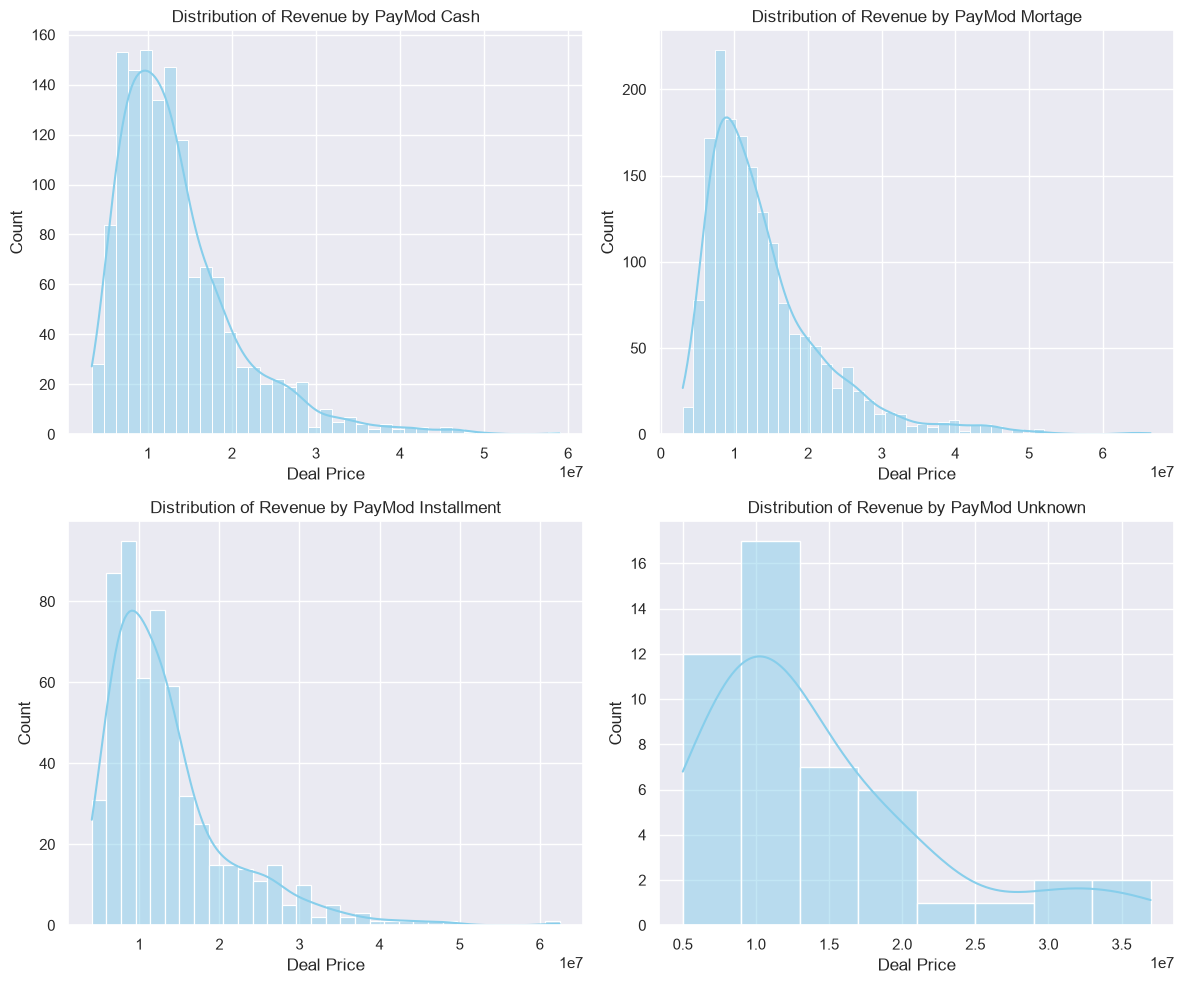

In [57]:
pm_cash = df_completed[df_completed['payment_mode']=='Cash']
pm_mortgage = df_completed[df_completed['payment_mode']=='Mortgage']
pm_installment = df_completed[df_completed['payment_mode']=='Installment']
pm_unknown = df_completed[df_completed['payment_mode']=='Unknown']


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(\
    data = pm_cash['deal_price'],
    kde=True,
    color='skyblue',
    ax=axes[0,0]
)

axes[0,0].set_title('Distribution of Revenue by PayMod Cash')
axes[0,0].set_xlabel('Deal Price')

sns.histplot(\
    data = pm_mortgage['deal_price'],
    kde=True,
    color='skyblue',
    ax=axes[0,1]
)

axes[0,1].set_title('Distribution of Revenue by PayMod Mortage')
axes[0,1].set_xlabel('Deal Price')

sns.histplot(\
    data = pm_installment['deal_price'],
    kde=True,
    color='skyblue',
    ax=axes[1,0]
)

axes[1,0].set_title('Distribution of Revenue by PayMod Installment')
axes[1,0].set_xlabel('Deal Price')

sns.histplot(\
    data = pm_unknown['deal_price'],
    kde=True,
    color='skyblue',
    ax=axes[1,1]
)

axes[1,1].set_title('Distribution of Revenue by PayMod Unknown')
axes[1,1].set_xlabel('Deal Price')


plt.tight_layout()
plt.show()

>1) CITY PERFORMANCE

>> a) Sales Performance by City

C:\Users\HP\AppData\Local\Temp\ipykernel_3636\2649650308.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_3636\2649650308.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(rev_city["city"])


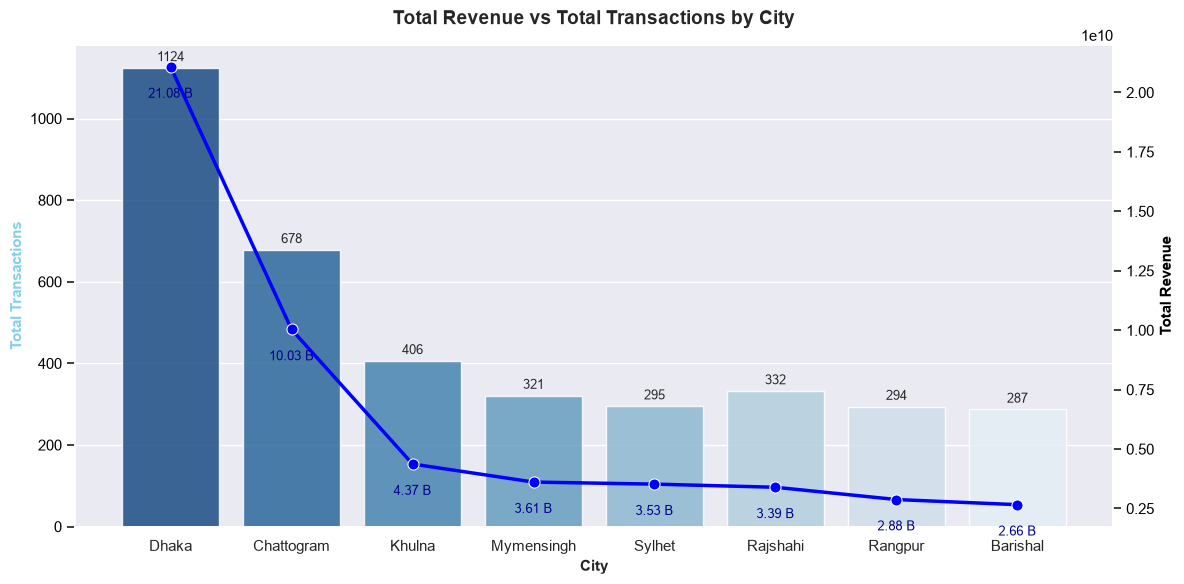

------------------ Sales Performance by City ------------------
Best Performing City by Rev   : Dhaka (21.08 B)
Worst Performing City by Rev  : Barishal (2.66 B)
----------------------------------------------------------------
Highest Transaction Volume    : Dhaka (1124)
Lowest Transaction Volume     : Barishal (287)
----------------------------------------------------------------
Highest Average Revenue per Transaction by City :  Dhaka (18.75 M)
Lowest Average Revenue per Transaction by City  : Barishal (9.27 M)


,city,total_rev,total_trans,avg_rev_per_trans,total_dicount
0,Dhaka,2.107547e+10,1124,1.875042e+07,181810057.0
1,Chattogram,1.002952e+10,678,1.479280e+07,165305159.0
2,Khulna,4.370173e+09,406,1.076397e+07,124328911.0
3,Mymensingh,3.611587e+09,321,1.125105e+07,106184822.0
4,Sylhet,3.525160e+09,295,1.194970e+07,74314866.0
5,Rajshahi,3.392819e+09,332,1.021933e+07,105348183.0
6,Rangpur,2.876720e+09,294,9.784761e+06,105390555.0
7,Barishal,2.660260e+09,287,9.269198e+06,92160629.0


In [69]:
rev_city = (\
    df_completed
    .groupby('city')
    .agg(total_rev = ('deal_price','sum'),
         total_trans = ('transaction_id','count'),
         avg_rev_per_trans = ('deal_price','mean'),
         total_dicount = ('diff_price',lambda x: x[df_completed.loc[x.index,'pricing_status']=='Discount'].sum()))
         .sort_values('total_rev', ascending= False)
         .reset_index()
)

sns.set_theme(style="darkgrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=rev_city,
    x="city",
    y="total_trans",
    palette="Blues_r",
    alpha=0.85,
    ax=ax1
)

ax1.set_xlabel("City", fontsize=11, fontweight="bold")
ax1.set_ylabel(
    "Total Transactions",
    fontsize=11,
    fontweight="bold",
    color="skyblue"
)
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_xticklabels(rev_city["city"])

for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt='%d',
        padding=3,
        fontsize=9
    )

ax2 = ax1.twinx()

sns.lineplot(
    data=rev_city,
    x="city",
    y="total_rev",
    color="blue",
    marker="o",
    linewidth=2.5,
    markersize=8,
    ax=ax2
)

ax2.set_ylabel(
    "Total Revenue",
    fontsize=11,
    fontweight="bold",
    color="black"
)
ax2.tick_params(axis="y", labelcolor="black")
ax2.grid(False)

for i, value in enumerate(rev_city["total_rev"]):
    ax2.annotate(
        f"{value / 1e9:.2f} B",
        (i, value),
        textcoords="offset points",
        xytext=(0, -15),
        ha="center",
        va="top",
        fontsize=9,
        color="darkblue"
    )

plt.title(
    "Total Revenue vs Total Transactions by City",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

print('------------------ Sales Performance by City ------------------')
worst_rev = rev_city['total_rev'].min()
best_rev = rev_city['total_rev'].max()
worst_rev_city = rev_city.loc[rev_city['total_rev'].idxmin()]
best_rev_city = rev_city.loc[rev_city['total_rev'].idxmax()]
print(f"Best Performing City by Rev   :\
 {best_rev_city['city']} ({best_rev/1e9:.2f} B)") 
print(f"Worst Performing City by Rev  :\
 {worst_rev_city['city']} ({worst_rev/1e9:.2f} B)") 

print('----------------------------------------------------------------')
lowest_trans_city = rev_city.loc[rev_city['total_trans'].idxmin()]
highest_trans_city = rev_city.loc[rev_city['total_trans'].idxmax()]
print(f"Highest Transaction Volume    :\
 {highest_trans_city['city']} ({rev_city['total_trans'].max()})")
print(f"Lowest Transaction Volume     :\
 {lowest_trans_city['city']} ({rev_city['total_trans'].min()})")

print('----------------------------------------------------------------')
lowest_avg_rev = rev_city['avg_rev_per_trans'].min()
highest_avg_rev = rev_city['avg_rev_per_trans'].max()
lowest_avg_rev_city = rev_city.loc[rev_city['avg_rev_per_trans'].idxmin()]
highest_avg_rev_city = rev_city.loc[rev_city['avg_rev_per_trans'].idxmax()]
print(f"Highest Average Revenue per Transaction by City : \
 {highest_avg_rev_city['city']} ({highest_avg_rev/1e6:.2f} M)")
print(f"Lowest Average Revenue per Transaction by City  :\
 {lowest_avg_rev_city['city']} ({lowest_avg_rev/1e6:.2f} M)")


rev_city

>>b) Revenue Contribution by City

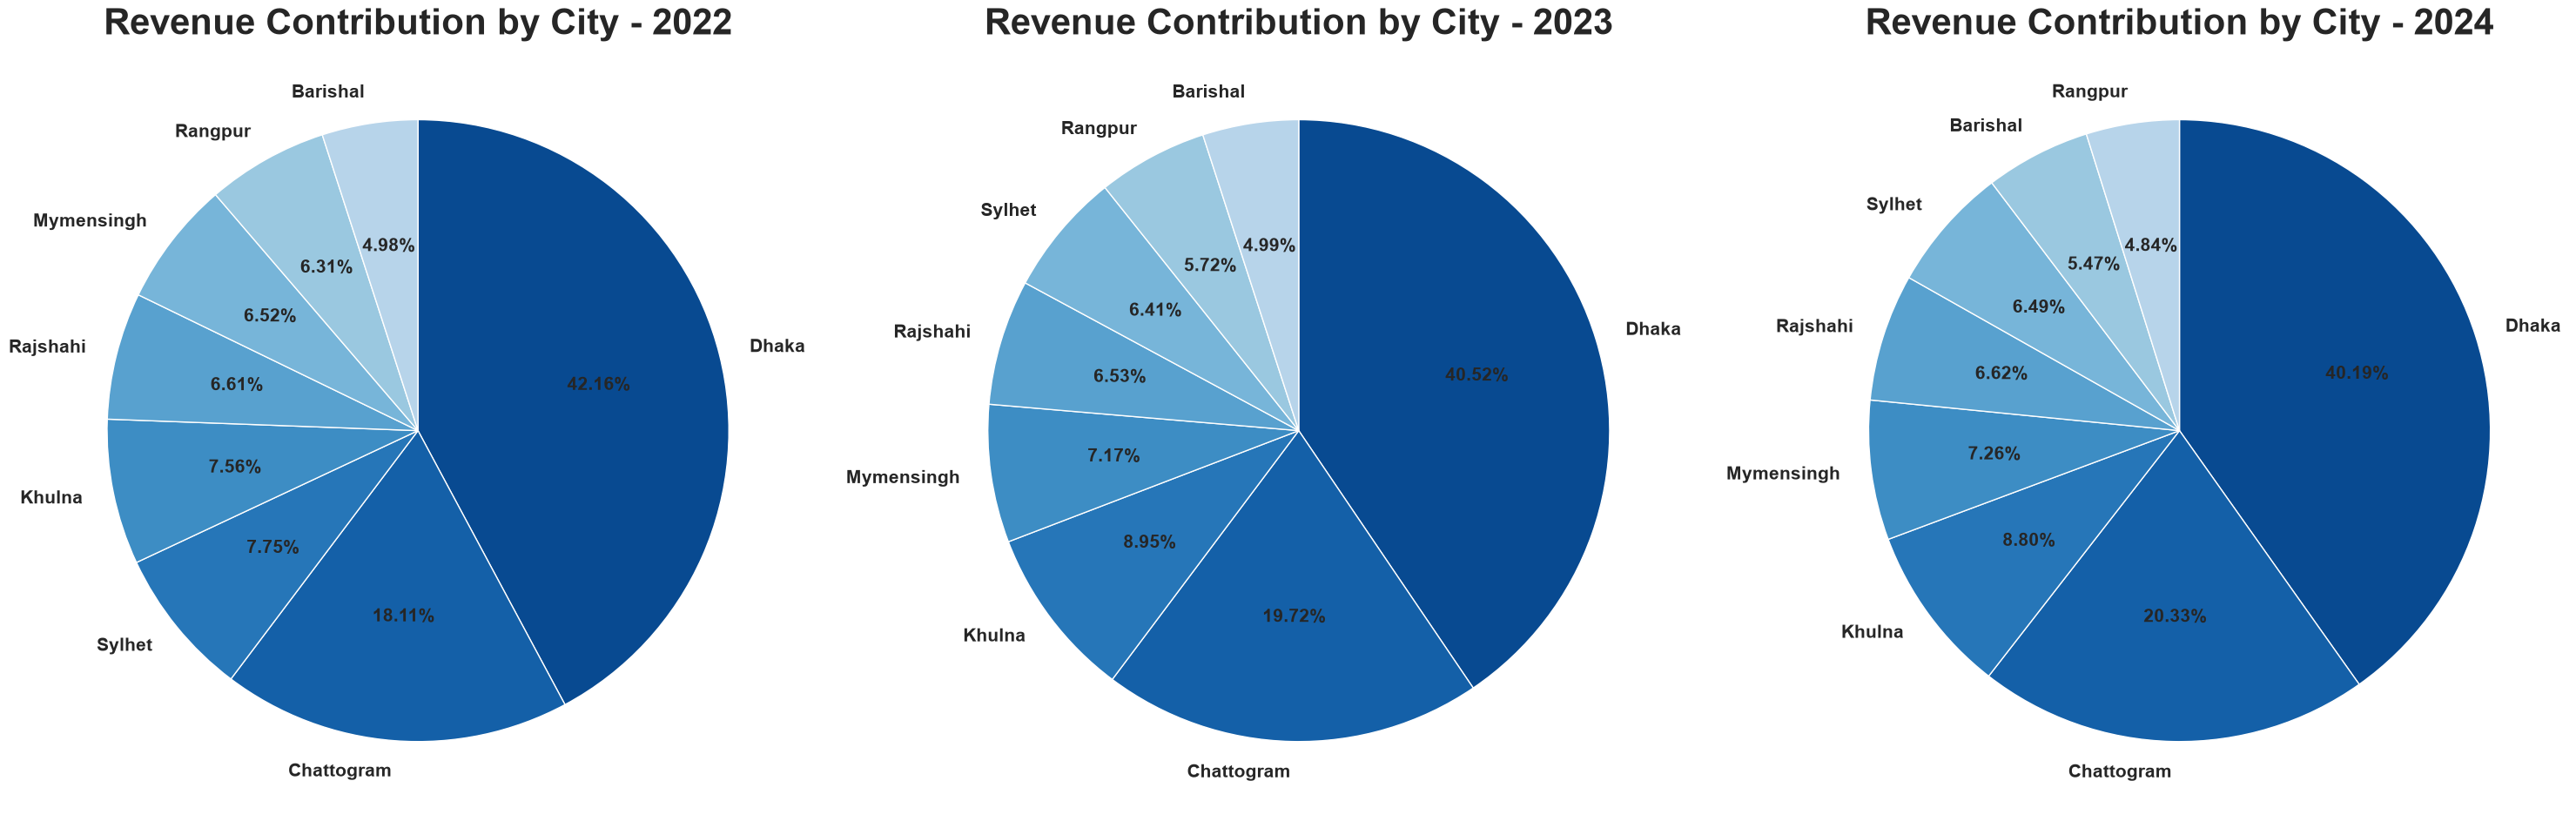

In [59]:
rev_year_city = (\
    df_completed
    .groupby(['year','city'])
    .agg(total_rev = ('deal_price','sum'),
         total_trans = ('transaction_id','count'))
    .reset_index()
)

years = rev_year_city['year'].unique()

fig, axes = plt.subplots(
    1,
    len(years),
    figsize=(30, 15)
)

for ax, year in zip(axes, years):

    data = (
        rev_year_city[rev_year_city['year'] == year]
        .sort_values('total_rev', ascending=False)
    )

    colors = plt.cm.Blues(np.linspace(0.9, 0.3, len(data)))

    ax.pie(\
        data['total_rev'],
        labels=data['city'],
        autopct='%1.2f%%',
        startangle=90,
        counterclock=False,
        colors=colors,
        wedgeprops={'edgecolor':'white'},
        textprops={'fontsize':15, 'fontweight':'bold'}
    )

    ax.set_title(\
        f'Revenue Contribution by City - {year}',
        fontsize=30,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


>> The market is heavily concentrated in two major cities: Dhaka (BDT 21.08B, 40.9%) and Chattogram (BDT 10.03B, 19.5%). Combined, these two cities contributed more than 60% of total revenue generated between 2022 and 2024. The annual revenue trend also shows consistent growth in both cities year over year, indicating stable and increasing market demand in these areas.

>> Most cities showed steady annual revenue growth from 2022 to 2024, with the exception of Rangpur and Sylhet. In Sylhet, revenue fluctuations were mainly driven by changes in the average revenue per transaction, while in Rangpur they were largely the result of declining transaction volumes. Despite these differences, each city's contribution to total annual revenue remained relatively stable throughout the analysis period, suggesting that the overall geographic distribution of the market changed very little over time

>> Overall, the stable contribution of each city indicates that the agency's revenue remains concentrated in established markets, with Dhaka and Chattogram continuing to serve as the primary revenue drivers.

> 3) PROPERTY PERFORMANCE

>> a) Sales Performance by Property

C:\Users\HP\AppData\Local\Temp\ipykernel_3636\209818317.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_3636\209818317.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(prop_perform["property_type"])


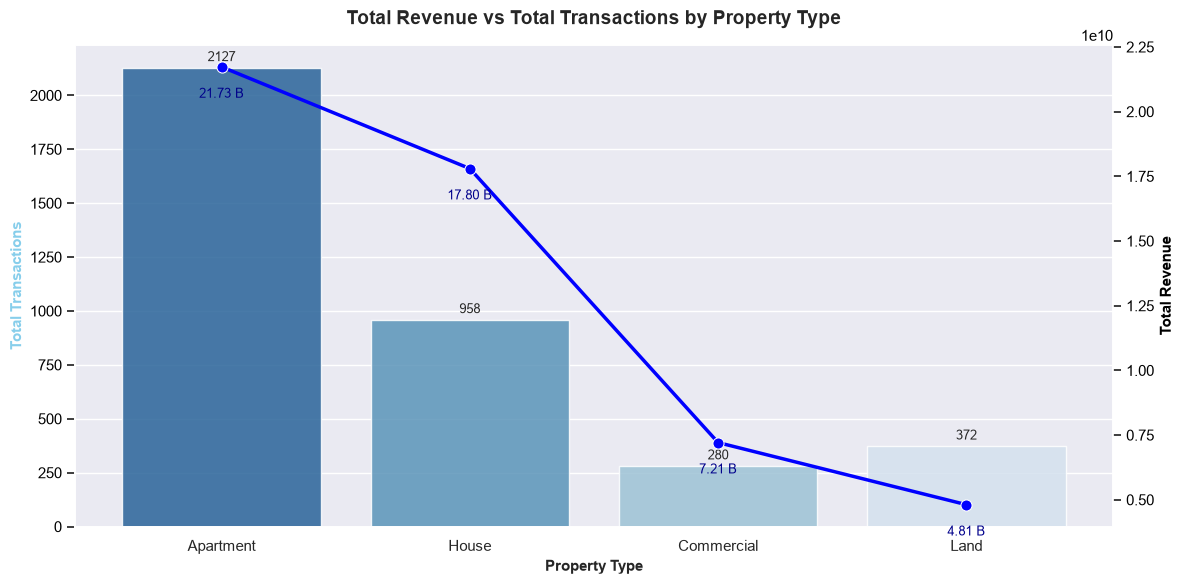

------------------ Sales Performance by Property ------------------
Best Performing Properties by Rev  : Apartment (21.73 B)
Worst Performing Properties by Rev : Land (4.81 B)
-------------------------------------------------------------------
Highest Transaction Volume : Apartment (2127)
Lowest Transaction Volume  :  Commercial (280)
-------------------------------------------------------------------
Highest Average Revenue per Transaction :  Commercial (25.74 M)


,property_type,total_rev,total_trans,avg_rev_per_trans,total_dicount
0,Apartment,2.172824e+10,2127,1.021544e+07,395078394.0
1,House,1.779648e+10,958,1.857670e+07,343517686.0
2,Commercial,7.208457e+09,280,2.574449e+07,124751271.0
3,Land,4.808529e+09,372,1.292615e+07,91495831.0


In [65]:
prop_perform = (\
    df_completed
    .groupby('property_type')
    .agg(total_rev = ('deal_price','sum'),
         total_trans = ('transaction_id','count'),
         avg_rev_per_trans = ('deal_price','mean'),
         total_dicount = ('diff_price',lambda x: x[df_completed.loc[x.index,'pricing_status']=='Discount'].sum()))
         .sort_values('total_rev', ascending= False)
         .reset_index()
)

sns.set_theme(style="darkgrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=prop_perform,
    x="property_type",
    y="total_trans",
    palette="Blues_r",
    alpha=0.85,
    ax=ax1
)

ax1.set_xlabel("Property Type", fontsize=11, fontweight="bold")
ax1.set_ylabel(
    "Total Transactions",
    fontsize=11,
    fontweight="bold",
    color="skyblue"
)
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_xticklabels(prop_perform["property_type"])

for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt='%d',
        padding=3,
        fontsize=9
    )

ax2 = ax1.twinx()

sns.lineplot(
    data=prop_perform,
    x="property_type",
    y="total_rev",
    color="blue",
    marker="o",
    linewidth=2.5,
    markersize=8,
    ax=ax2
)

ax2.set_ylabel(
    "Total Revenue",
    fontsize=11,
    fontweight="bold",
    color="black"
)
ax2.tick_params(axis="y", labelcolor="black")
ax2.grid(False)

for i, value in enumerate(prop_perform["total_rev"]):
    ax2.annotate(
        f"{value / 1e9:.2f} B",
        (i, value),
        textcoords="offset points",
        xytext=(0, -15),
        ha="center",
        va="top",
        fontsize=9,
        color="darkblue"
    )

plt.title(
    "Total Revenue vs Total Transactions by Property Type",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

print('------------------ Sales Performance by Property ------------------')
best_rev_prop = prop_perform.loc[prop_perform['total_rev'].idxmax()]
worst_rev_prop = prop_perform.loc[prop_perform['total_rev'].idxmin()]
print(f"Best Performing Properties by Rev  :\
 {best_rev_prop['property_type']} ({(prop_perform['total_rev'].max())/1e9:.2f} B)")
print(f"Worst Performing Properties by Rev :\
 {worst_rev_prop['property_type']} ({(prop_perform['total_rev'].min())/1e9:.2f} B)")

print('-------------------------------------------------------------------')
worst_trans_prop = prop_perform.loc[prop_perform['total_trans'].idxmin()]
best_trans_prop = prop_perform.loc[prop_perform['total_trans'].idxmax()]
print(f"Highest Transaction Volume :\
 {best_trans_prop['property_type']} ({prop_perform['total_trans'].max()})")
print(f"Lowest Transaction Volume  : \
 {worst_trans_prop['property_type']} ({prop_perform['total_trans'].min()})")
print('-------------------------------------------------------------------')
best_avg_rev_prop = prop_perform.loc[prop_perform['avg_rev_per_trans'].idxmax()]
print(f"Highest Average Revenue per Transaction : \
 {best_avg_rev_prop['property_type']} ({(prop_perform['avg_rev_per_trans'].max())/1e6:.2f} M)")

prop_perform

>>b) Revenue Contribution by Property

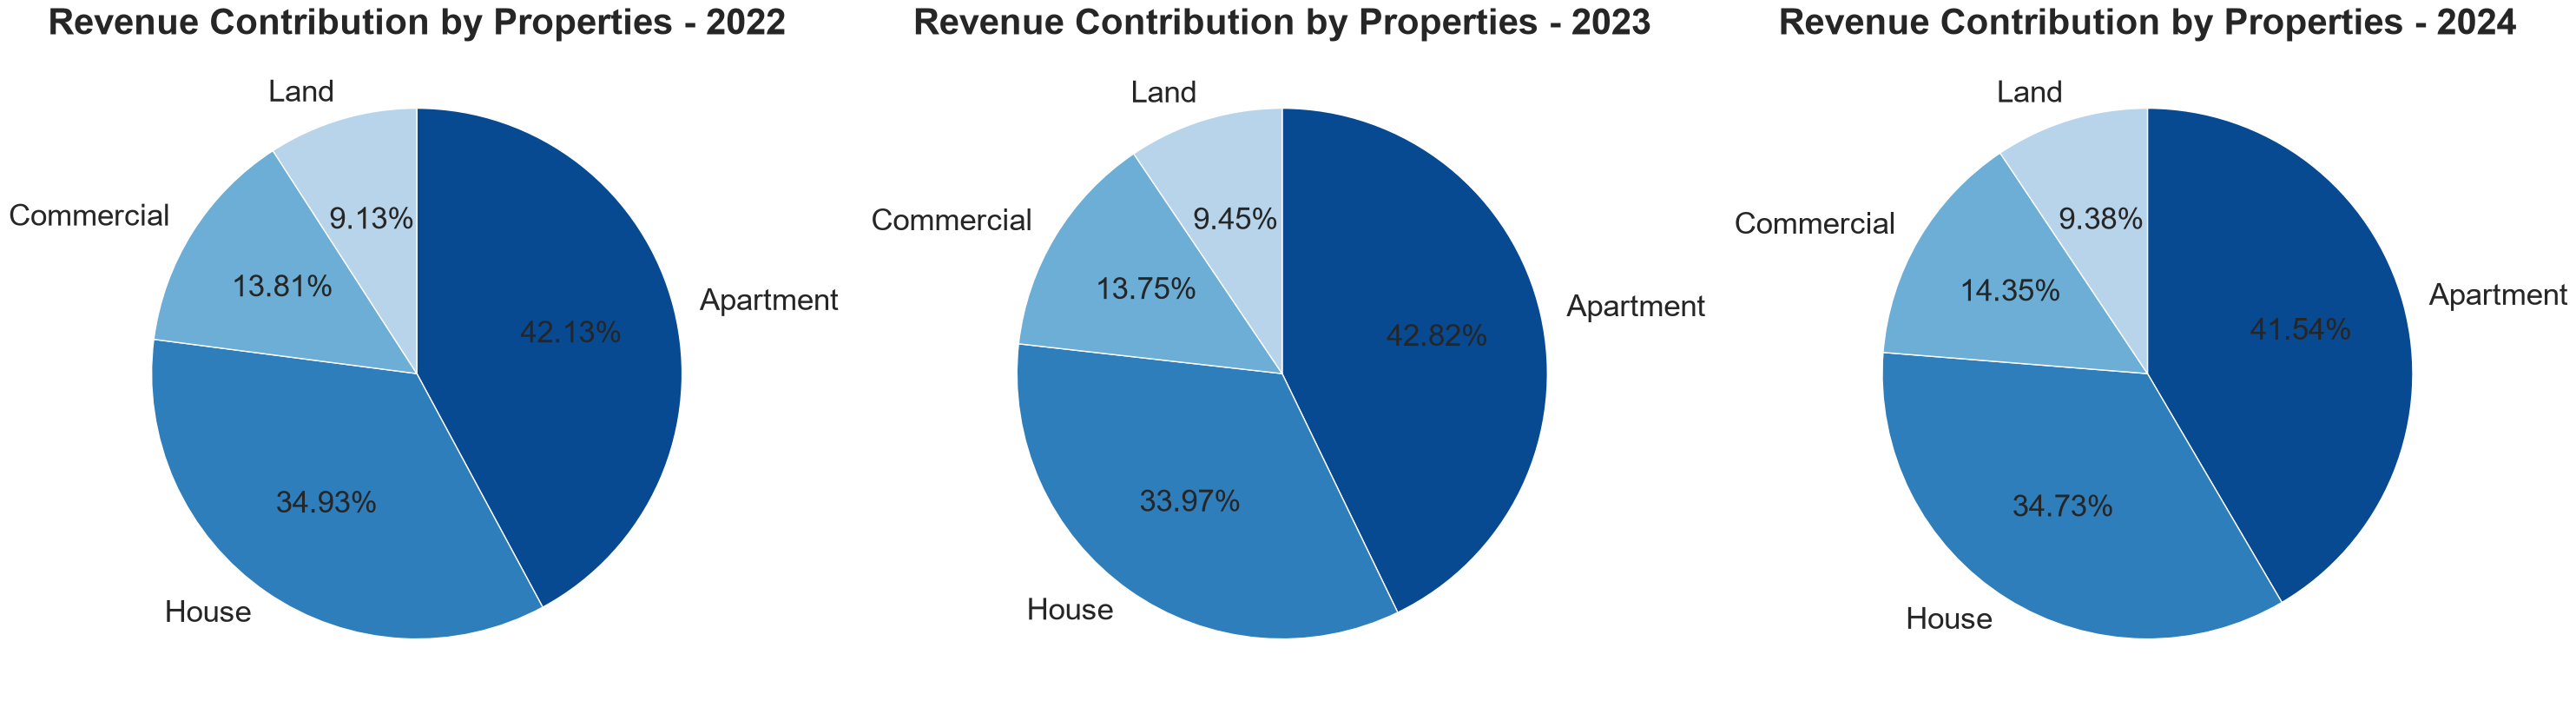

In [61]:
rev_year_prop = (\
    df_completed
    .groupby(['year','property_type'])
    .agg(total_rev = ('deal_price','sum'),
         total_trans = ('transaction_id','count'))
         .reset_index()
         .sort_values('year')
)

years = rev_year_prop['year'].unique()

fig, axes = plt.subplots(\
    1,   
    len(years),            
    figsize=(30, 15)
)

for ax, year in zip(axes, years):
    
    data = rev_year_prop[rev_year_prop['year'] == year].sort_values('total_rev', ascending = False)

    colors = plt.cm.Blues(np.linspace(0.9,0.3, len(data)))
    
    ax.pie(\
        data['total_rev'],
        labels=data['property_type'],
        autopct='%1.2f%%',
        startangle=90,
        counterclock=False,
        colors = colors,
        wedgeprops={'edgecolor':'white'},
        textprops = {'fontsize': 25}
    )
    
    ax.set_title(\
        f'Revenue Contribution by Properties - {year}',
        fontsize=30,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

>>1. Apartments generated the highest revenue contribution at BDT 21.72B (42.16%), driven by the highest transaction volume with 2,127 deals (>50% of total transactions). Apartments also had the shortest Days on Market, indicating a fast conversion cycle. However, the lower average transaction value suggests that most apartment sales were concentrated in more affordable property segments
>>
>> 2. Houses were the second-largest revenue contributor after apartments, generating BDT 17.79B (34.53%) of total revenue. Together, apartments and houses accounted for more than 70% of total revenue during the analysis period. Compared to apartments, houses had a higher average transaction value while maintaining strong transaction volume (958 deals). Despite their higher value, houses had an average Days on Market of around 46 days, indicating a relatively fast sales cycle
>>
>>3. Commercial properties recorded the highest average transaction value among all property types, reaching BDT 25.74M. This indicates that represent a higher-value market segment in the premium segment. Unlike apartments, which are mainly driven by transaction volume, commercial property revenue is primarily supported by the higher value of each transaction
>>
>>4. Land properties generated BDT 4.81B in revenue, contributing 9.33% of total revenue from 372 transactions. The average transaction value of BDT 12.93M places land in the mid-value segment, while the 48-day average Days on Market suggests a relatively slower sales cycle compared to other property types

>> The annual revenue trend shows positive growth across all property types from 2022 to 2024, reflecting improved transaction performance across different segments. However, apartments remained the dominant revenue contributor throughout the analysis period, highlighting their importance as the main driver of the agency’s revenue performanc